# Random Forest Regression

## What it does
**Random Forest** is an ensemble of decision trees trained on bootstrap samples of the data,
with a random subset of features considered at each split:

$$\hat{y} = \frac{1}{B} \sum_{b=1}^{B} T_b(x)$$

The combination of bagging (bootstrap aggregation) and random feature subsets reduces variance
while maintaining low bias, producing robust predictions that generalize well.

## Key hyperparameters
| Parameter | Effect |
|---|---|
| `n_estimators` | Number of trees — more trees reduce variance (diminishing returns after ~500) |
| `max_features` | Features per split: `'sqrt'` or `'log2'` or fraction — controls decorrelation |
| `max_depth` | Maximum tree depth — limits complexity and prevents overfitting |
| `min_samples_leaf` | Minimum leaf size — regularizes tree depth |

## When to use it
- Strong non-linear baseline alongside GBR and neural networks
- Features are on different scales (no standardization needed — tree splits are scale-invariant)
- You want built-in feature importance estimates

## Data format
Panel CSV/Parquet with `DATE_COL`, `ID_COL`, `TARGET_COL`; all other numeric columns are features.

## Configuration

In [1]:
CONFIG = {
    # --- Data ---
    'DATA_FILE':          '../../data/largeml.pq',
    'DATE_COL':           'yyyymm',
    'ID_COL':             'permno',
    'TARGET_COL':         'ret',
    # --- Time splits (year-based) ---
    'TRAIN_YEARS':        20,
    'VAL_YEARS':          12,
    # --- Preprocessing ---
    'MISSING_FILL_VALUE': 0,
    'STANDARDIZE':        False,    # Not needed for tree-based models
    # --- Random Forest grid ---
    'N_ESTIMATORS_GRID':  [100, 300, 500],
    'MAX_FEATURES_GRID':  ['sqrt', 'log2', 0.3],
    'MAX_DEPTH_GRID':     [3, 5, None],      # None = grow full trees
    'MIN_SAMPLES_LEAF':   5,                 # light regularization
    'RF_RANDOM_STATE':    42,
    'N_JOBS':             -1,                # use all CPU cores
    # --- Portfolio ---
    'N_DECILES':          10,
    # --- Output ---
    'SAVE_RESULTS':       True,
    'OUTPUT_DIR':         '../../results',
}

print('Configuration loaded.')
for k, v in CONFIG.items():
    print(f'  {k}: {v}')

Configuration loaded.
  DATA_FILE: ../../data/largeml.pq
  DATE_COL: yyyymm
  ID_COL: permno
  TARGET_COL: ret
  TRAIN_YEARS: 20
  VAL_YEARS: 12
  MISSING_FILL_VALUE: 0
  STANDARDIZE: False
  N_ESTIMATORS_GRID: [100, 300, 500]
  MAX_FEATURES_GRID: ['sqrt', 'log2', 0.3]
  MAX_DEPTH_GRID: [3, 5, None]
  MIN_SAMPLES_LEAF: 5
  RF_RANDOM_STATE: 42
  N_JOBS: -1
  N_DECILES: 10
  SAVE_RESULTS: True
  OUTPUT_DIR: results


## Step 1 — Load Data & Define Time Splits

In [2]:
import sys, warnings, os, itertools
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path('../../').resolve()))
from utils import (
    load_parquet, time_series_split, prepare_panel_data,
    standardize_splits, drop_na_targets,
    compute_oos_r2, evaluate_splits,
    form_long_short_portfolio, portfolio_summary,
    build_run_summary, save_run_summary, save_portfolio_compositions,
)

df = load_parquet(CONFIG['DATA_FILE'])
df[CONFIG['DATE_COL']] = pd.to_numeric(df[CONFIG['DATE_COL']])
print(f'Dataset shape : {df.shape}')
print(f'Date range    : {df[CONFIG["DATE_COL"]].min()} — {df[CONFIG["DATE_COL"]].max()}')
df.head()

Dataset shape : (79146, 212)
Date range    : 192512 — 202211


,permno,yyyymm,AM,AOP,AbnormalAccruals,Accruals,AccrualsBM,Activism1,Activism2,AdExp,...,roaq,sfe,sinAlgo,skew1,std_turn,tang,zerotrade12M,zerotrade1M,zerotrade6M,ret
0,10078,198606,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.393044e-08,NaN,-0.118056
1,10078,198607,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.737205e-08,NaN,-0.039370
2,10078,198609,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.597698e-08,1.857281e-07,-0.008850
3,10078,198610,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.763825e-08,2.111030e-07,0.348214
4,10078,198612,0.236302,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.718727,NaN,5.878542e-09,8.619326e-08,0.109827


In [3]:
train_mask, val_mask, test_mask, split_info = time_series_split(
    df, date_col=CONFIG['DATE_COL'],
    train_years=CONFIG['TRAIN_YEARS'], val_years=CONFIG['VAL_YEARS'],
)
print(f"Training   : {split_info['train_start']} — {split_info['train_end']}  ({split_info['train_n_obs']:,} obs)")
print(f"Validation : {split_info['val_start']}   — {split_info['val_end']}    ({split_info['val_n_obs']:,} obs)")
print(f"Test       : {split_info['test_start']}   — {split_info['test_end']}    ({split_info['test_n_obs']:,} obs)")

Training   : 1925 — 1944  (889 obs)
Validation : 1945   — 1956    (709 obs)
Test       : 1957   — 2022    (77,548 obs)


## Step 2 — Prepare Features

In [4]:
X, y, feature_cols = prepare_panel_data(
    df, target_col=CONFIG['TARGET_COL'],
    exclude_cols=[CONFIG['DATE_COL'], CONFIG['ID_COL']],
    fill_value=CONFIG['MISSING_FILL_VALUE'],
)

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

(X_train, y_train), (X_val, y_val), (X_test, y_test) = drop_na_targets(
    (X_train, y_train), (X_val, y_val), (X_test, y_test)
)

if CONFIG['STANDARDIZE']:
    X_train, X_val, X_test, scaler = standardize_splits(X_train, X_val, X_test)
    print('Features standardized (fit on training data only).')
else:
    print('No standardization (tree-based model — scale invariant).')

y_train_mean = float(y_train.mean())
print(f'Features      : {len(feature_cols)}')
print(f'Train obs     : {X_train.shape[0]:,}')
print(f'Training mean : {y_train_mean:.6f}')

No standardization (tree-based model — scale invariant).
Features      : 209
Train obs     : 884
Training mean : 0.007120


## Step 3 — Grid Search: n_estimators × max_features × max_depth

Best hyperparameters selected by **validation OOS R²** — test set never touched.

In [5]:
grid_results = []

combos = list(itertools.product(
    CONFIG['N_ESTIMATORS_GRID'],
    CONFIG['MAX_FEATURES_GRID'],
    CONFIG['MAX_DEPTH_GRID'],
))
print(f'Grid size: {len(combos)} combinations')
print('=' * 70)

for n_est, max_feat, max_depth in combos:
    rf = RandomForestRegressor(
        n_estimators    = n_est,
        max_features    = max_feat,
        max_depth       = max_depth,
        min_samples_leaf= CONFIG['MIN_SAMPLES_LEAF'],
        random_state    = CONFIG['RF_RANDOM_STATE'],
        n_jobs          = CONFIG['N_JOBS'],
    )
    rf.fit(X_train, y_train)
    val_pred = rf.predict(X_val)
    oos_r2   = compute_oos_r2(y_val.values, val_pred, y_train_mean)
    grid_results.append({
        'n_estimators': n_est, 'max_features': max_feat,
        'max_depth': max_depth, 'oos_r2_val': oos_r2, 'model': rf,
    })
    print(f'  n_est={n_est:4d}  max_feat={str(max_feat):6s}  depth={str(max_depth):6s}  '
          f'Val OOS R²={oos_r2*100:+.4f}%')

best = max(grid_results, key=lambda r: r['oos_r2_val'])
print(f"\nBest: n_estimators={best['n_estimators']}, max_features={best['max_features']}, "
      f"max_depth={best['max_depth']}  (Val OOS R² = {best['oos_r2_val']*100:+.4f}%)")

Grid size: 27 combinations


  n_est= 100  max_feat=sqrt    depth=3       Val OOS R²=+13.0784%
  n_est= 100  max_feat=sqrt    depth=5       Val OOS R²=+20.0743%


  n_est= 100  max_feat=sqrt    depth=None    Val OOS R²=+27.9038%
  n_est= 100  max_feat=log2    depth=3       Val OOS R²=+7.5795%


  n_est= 100  max_feat=log2    depth=5       Val OOS R²=+11.2169%


  n_est= 100  max_feat=log2    depth=None    Val OOS R²=+17.9085%
  n_est= 100  max_feat=0.3     depth=3       Val OOS R²=+30.9691%


...

  n_est= 500  max_feat=log2    depth=5       Val OOS R²=+12.6286%


  n_est= 500  max_feat=log2    depth=None    Val OOS R²=+18.4493%


  n_est= 500  max_feat=0.3     depth=3       Val OOS R²=+33.2670%


  n_est= 500  max_feat=0.3     depth=5       Val OOS R²=+38.7192%


  n_est= 500  max_feat=0.3     depth=None    Val OOS R²=+43.8722%

Best: n_estimators=300, max_features=0.3, max_depth=None  (Val OOS R² = +44.2211%)


## Step 4 — Final Evaluation on All Splits

In [6]:
best_model = best['model']

preds = {
    'train': best_model.predict(X_train),
    'val':   best_model.predict(X_val),
    'test':  best_model.predict(X_test),
}

metrics = evaluate_splits(
    y_train, preds['train'], y_val, preds['val'], y_test, preds['test'],
    train_mean=y_train_mean,
)

print('RANDOM FOREST — BEST MODEL EVALUATION')
print('=' * 55)
print(f"  n_estimators   : {best['n_estimators']}")
print(f"  max_features   : {best['max_features']}")
print(f"  max_depth      : {best['max_depth']}")
print()
print(f"  Train R²       : {metrics['r2_train']*100:+.4f}%")
print(f"  Val R²         : {metrics['r2_val']*100:+.4f}%")
print(f"  Test R²        : {metrics['r2_test']*100:+.4f}%")
print()
print(f"  OOS R² Val     : {metrics['oos_r2_val']*100:+.4f}%")
print(f"  OOS R² Test    : {metrics['oos_r2_test']*100:+.4f}%")
print('=' * 55)

RANDOM FOREST — BEST MODEL EVALUATION
  n_estimators   : 300
  max_features   : 0.3
  max_depth      : None

  Train R²       : +74.5520%
  Val R²         : +43.2249%
  Test R²        : +23.8448%

  OOS R² Val     : +44.2211%
  OOS R² Test    : +24.2695%


## Step 5 — Feature Importances

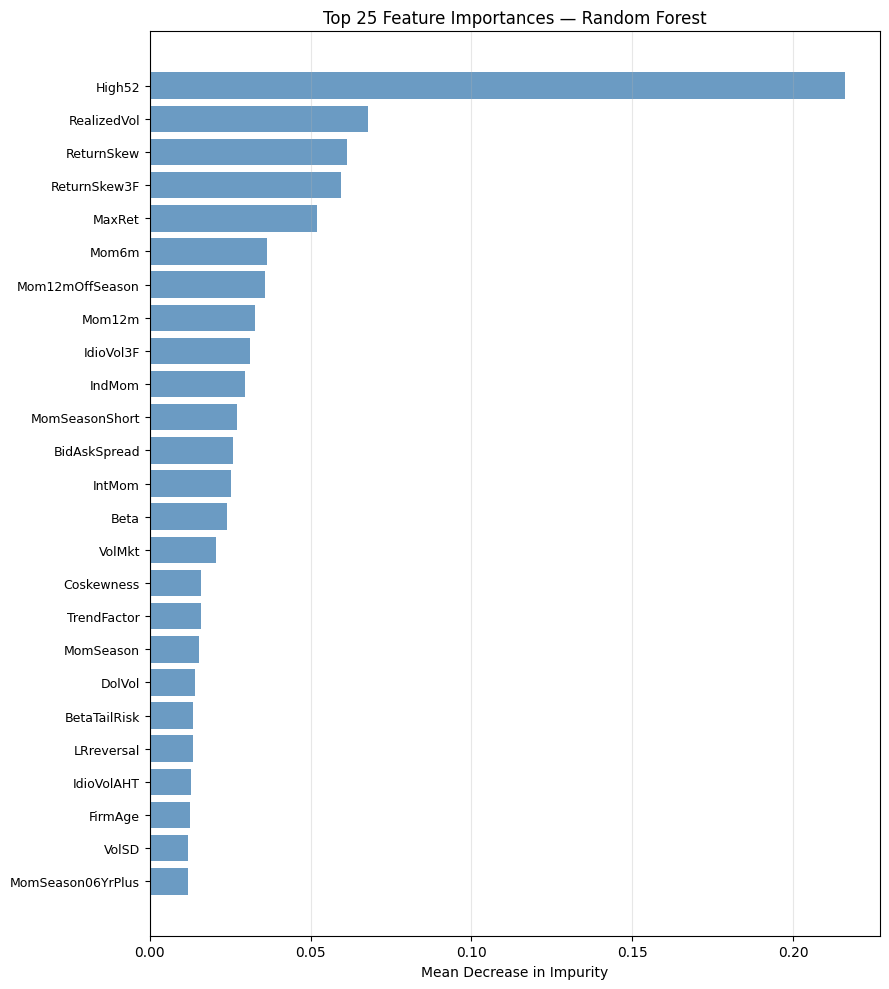


Top 10 features:
        feature  importance
         High52    0.216245
    RealizedVol    0.067778
     ReturnSkew    0.061220
   ReturnSkew3F    0.059613
         MaxRet    0.051997
          Mom6m    0.036418
Mom12mOffSeason    0.035801
         Mom12m    0.032648
      IdioVol3F    0.031287
         IndMom    0.029746


In [7]:
importances = best_model.feature_importances_
imp_df = pd.DataFrame({
    'feature':    feature_cols,
    'importance': importances,
}).sort_values('importance', ascending=False)

top_n = min(25, len(imp_df))
top_df = imp_df.head(top_n)

fig, ax = plt.subplots(figsize=(9, max(4, top_n * 0.4)))
ax.barh(range(top_n), top_df['importance'].values, color='steelblue', alpha=0.8)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_df['feature'].values, fontsize=9)
ax.invert_yaxis()
ax.set(xlabel='Mean Decrease in Impurity', title=f'Top {top_n} Feature Importances — Random Forest')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print(f'\nTop 10 features:')
print(imp_df.head(10).to_string(index=False))

## Step 6 — Portfolio Formation & Sharpe Ratio

RANDOM FOREST LONG-SHORT PORTFOLIO
  Months         : 552
  Mean monthly   : 13.1307%
  Std monthly    : 7.4991%
  Sharpe (ann.)  : 6.0655


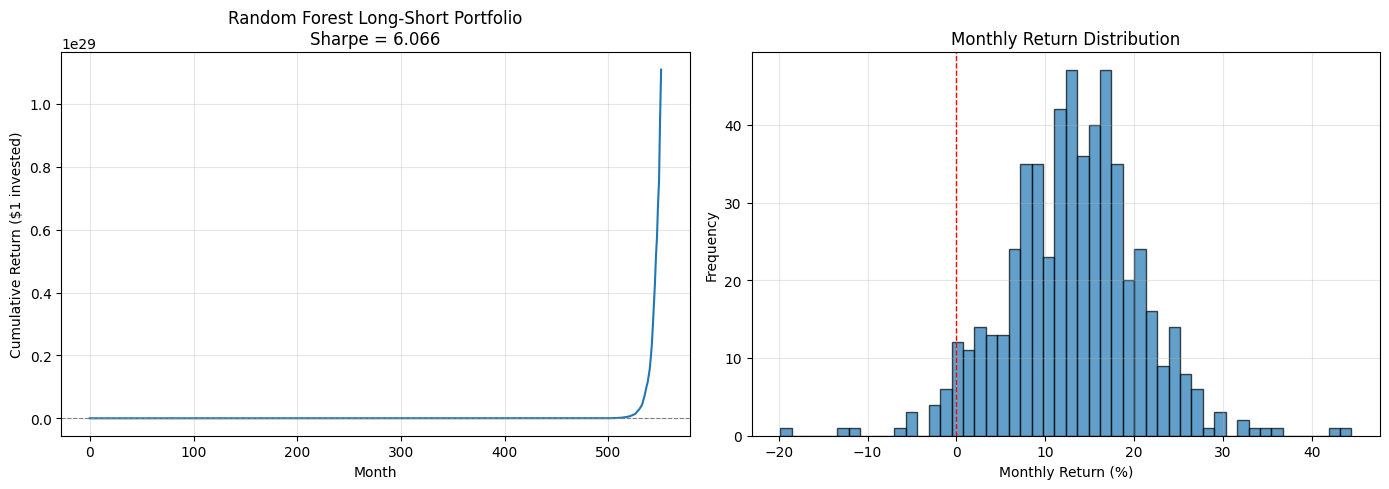

In [8]:
test_df_base = df.loc[y_test.index, [CONFIG['DATE_COL'], CONFIG['ID_COL'], CONFIG['TARGET_COL']]].copy()
test_df_base['predicted_ret'] = preds['test']
test_df_base = test_df_base.rename(columns={CONFIG['TARGET_COL']: 'actual_ret'})

port_returns, comp_df = form_long_short_portfolio(
    test_df_base, date_col=CONFIG['DATE_COL'],
    pred_col='predicted_ret', ret_col='actual_ret',
    n_deciles=CONFIG['N_DECILES'],
)
port_stats = portfolio_summary(port_returns)

print('RANDOM FOREST LONG-SHORT PORTFOLIO')
print('=' * 50)
print(f"  Months         : {port_stats['n_periods']}")
print(f"  Mean monthly   : {port_stats['mean_period_return']*100:.4f}%")
print(f"  Std monthly    : {port_stats['std_period_return']*100:.4f}%")
print(f"  Sharpe (ann.)  : {port_stats['sharpe_annualized']:.4f}")
print('=' * 50)

cumulative = (1 + port_returns).cumprod()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(len(cumulative)), cumulative.values, linewidth=1.5)
axes[0].axhline(y=1, color='gray', linestyle='--', linewidth=0.8)
axes[0].set(xlabel='Month', ylabel='Cumulative Return ($1 invested)',
            title=f'Random Forest Long-Short Portfolio\nSharpe = {port_stats["sharpe_annualized"]:.3f}')
axes[0].grid(True, alpha=0.3)
axes[1].hist(port_returns.values * 100, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1)
axes[1].set(xlabel='Monthly Return (%)', ylabel='Frequency', title='Monthly Return Distribution')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 7 — Save Results

In [9]:
if CONFIG['SAVE_RESULTS']:
    summary = build_run_summary(
        model_name    = 'Random Forest',
        description   = 'RandomForestRegressor — bagged trees with random feature subsets',
        tuning_params = (f"n_estimators={best['n_estimators']}, "
                         f"max_features={best['max_features']}, "
                         f"max_depth={best['max_depth']}"),
        metrics       = metrics,
        portfolio_stats = port_stats,
        split_info    = split_info,
        n_features    = len(feature_cols),
        fill_value    = CONFIG['MISSING_FILL_VALUE'],
        standardized  = CONFIG['STANDARDIZE'],
        notebook      = 'random_forest',
    )
    path = save_run_summary(summary, CONFIG['OUTPUT_DIR'], 'rf_summary.csv')
    print(f'Saved: {path}')
    path = save_portfolio_compositions(comp_df, CONFIG['OUTPUT_DIR'], 'rf_portfolios.csv')
    print(f'Saved: {path}')

    # Save feature importances
    imp_path = os.path.join(CONFIG['OUTPUT_DIR'], 'rf_feature_importances.csv')
    imp_df.to_csv(imp_path, index=False)
    print(f'Saved: {imp_path}')
else:
    print('SAVE_RESULTS = False — skipping.')

Saved: results/rf_summary.csv
Saved: results/rf_portfolios.csv
Saved: results/rf_feature_importances.csv
